In [2]:
# Celda 1: Importar Librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re # Para expresiones regulares en NLP

# Configuración de visualización (opcional)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Celda 2: Cargar el Dataset
try:
    df = pd.read_csv('dataset_sintetico_5000_ampliado.csv')
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'analisis_temas.csv' esté en la misma carpeta.")

In [4]:
df

,id,fecha,usuario,texto,tema,sentimiento,likes,reposts
0,1,2022-05-01,user_44220,La presión por ser productivo todo el tiempo e...,Generación Z y crisis de sentido,neutral,1056,2652
1,2,2024-03-21,user_8463,Antes los proyectos de vida eran a largo plazo...,Cultura de lo efímero y proyectos de vida,neutral,4032,566
2,3,2022-12-21,user_26421,Cada vez que una app me recomienda qué ver o q...,Cultura de lo efímero y proyectos de vida,neutral,7884,1817
3,4,2022-09-04,user_24985,Todo se mueve tan rápido que incluso los recue...,Cultura de lo efímero y proyectos de vida,neutral,8695,3614
4,5,2022-01-15,user_71752,¿Seguimos siendo sujetos libres si los algorit...,Cultura de lo efímero y proyectos de vida,negativo,16384,2610
...,...,...,...,...,...,...,...,...
4995,4996,2024-01-06,user_69059,La Generación Z enfrenta un dilema existencial...,IA y pérdida de autonomía humana,neutral,2617,1998
4996,4997,2023-02-27,user_711,Todo se mueve tan rápido que incluso los recue...,IA y pérdida de autonomía humana,neutral,10728,1707
4997,4998,2022-01-12,user_41449,Cada vez que una app me recomienda qué ver o q...,IA y pérdida de autonomía humana,negativo,13648,863
4998,4999,2024-04-29,user_38388,Los algoritmos parecen conocer mis gustos mejo...,Cultura de lo efímero y proyectos de vida,positivo,12331,1688


In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
%config IPCompleter.greedy=True

In [15]:
data = df['texto'].head(10)
data

0    La presión por ser productivo todo el tiempo e...
1    Antes los proyectos de vida eran a largo plazo...
2    Cada vez que una app me recomienda qué ver o q...
3    Todo se mueve tan rápido que incluso los recue...
4    ¿Seguimos siendo sujetos libres si los algorit...
5    Estamos tan acostumbrados a la recompensa inst...
6    Antes los proyectos de vida eran a largo plazo...
7    Antes los proyectos de vida eran a largo plazo...
8    Estamos tan acostumbrados a la recompensa inst...
9    El ruido constante de las redes sociales hace ...
Name: texto, dtype: object

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# Lista de stop words en español
stop_words_spanish = [
    'el', 'la', 'de', 'que', 'y', 'a', 'en', 'un', 'ser', 'se', 'no', 'haber',
    'por', 'con', 'su', 'para', 'como', 'estar', 'tener', 'le', 'lo', 'todo',
    'pero', 'más', 'hacer', 'o', 'poder', 'decir', 'este', 'ir', 'otro', 'ese',
    'la', 'si', 'me', 'ya', 'ver', 'porque', 'dar', 'cuando', 'él', 'muy',
    'sin', 'vez', 'mucho', 'saber', 'qué', 'sobre', 'mi', 'alguno', 'mismo',
    'yo', 'también', 'hasta', 'año', 'dos', 'querer', 'entre', 'así', 'primero',
    'desde', 'grande', 'eso', 'ni', 'nos', 'llegar', 'pasar', 'tiempo', 'ella',
    'sí', 'día', 'uno', 'bien', 'poco', 'deber', 'entonces', 'poner', 'cosa',
    'tanto', 'hombre', 'parecer', 'nuestro', 'tan', 'donde', 'ahora', 'parte',
    'después', 'vida', 'quedar', 'siempre', 'creer', 'hablar', 'llevar', 'dejar',
    'nada', 'cada', 'seguir', 'menos', 'nuevo', 'encontrar', 'algo', 'solo',
    'decir', 'puede', 'cómo', 'tres', 'momento', 'salir', 'tomar', 'mí', 'usted',
    'están', 'durante', 'quien', 'nunca', 'antes', 'cual', 'aunque', 'tras',
    'tal', 'acá', 'ahí', 'allá', 'allí', 'aquel', 'aquí', 'bajo', 'bastante',
    'cerca', 'claro', 'cuál', 'cuándo', 'cuánto', 'debajo', 'del', 'demás',
    'dentro', 'él', 'ésta', 'éste', 'esto', 'había', 'han', 'hay', 'les',
    'mía', 'mío', 'misma', 'mismo', 'mucha', 'muchas', 'muchos', 'nada',
    'nuestra', 'nuestras', 'nuestro', 'nuestros', 'otra', 'otras', 'otros',
    'poca', 'pocas', 'pocos', 'qué', 'quién', 'quiénes', 'sea', 'según',
    'serán', 'sido', 'siendo', 'son', 'soy', 'suya', 'suyas', 'suyo', 'suyos',
    'te', 'tendrá', 'tendrán', 'tengo', 'ti', 'tiene', 'tienen', 'toda',
    'todas', 'tuya', 'tuyas', 'tuyo', 'tuyos', 'vos', 'vosotras', 'vosotros',
    'vuestra', 'vuestras', 'vuestro', 'vuestros'
]

# Vectorización con stop words en español
count_vectorizer = CountVectorizer(stop_words=stop_words_spanish)
matrix = count_vectorizer.fit_transform(data)
data_matrix = matrix.todense()

# Crear DataFrame de frecuencias
frecuencias = pd.DataFrame(data_matrix, columns=count_vectorizer.get_feature_names_out())

# Calcular similaridad del coseno
salida = cosine_similarity(frecuencias, frecuencias)

# ============================================================
# ENCONTRAR TEXTOS SIMILARES AUTOMÁTICAMENTE
# ============================================================

def encontrar_textos_similares(matriz_similaridad, umbral=0.8):
    """
    Encuentra automáticamente pares de textos similares
    """
    pares_similares = []
    
    for i in range(len(matriz_similaridad)):
        for j in range(i+1, len(matriz_similaridad)):
            similaridad = matriz_similaridad[i][j]
            if similaridad >= umbral:
                pares_similares.append({
                    'texto_id_1': i,
                    'texto_id_2': j,
                    'similaridad': round(similaridad, 4)
                })
    
    df_similares = pd.DataFrame(pares_similares)
    if len(df_similares) > 0:
        df_similares = df_similares.sort_values('similaridad', ascending=False)
    
    return df_similares

# OPCIÓN 1: Encontrar textos muy similares (umbral alto)
print("="*60)
print("TEXTOS DUPLICADOS O CASI IDÉNTICOS (similaridad >= 0.95)")
print("="*60)
duplicados = encontrar_textos_similares(salida, umbral=0.95)
print(duplicados)
print()

# OPCIÓN 2: Encontrar textos similares (umbral medio)
print("="*60)
print("TEXTOS SIMILARES (similaridad >= 0.7)")
print("="*60)
similares = encontrar_textos_similares(salida, umbral=0.7)
print(similares)
print()

# OPCIÓN 3: Para cada texto, mostrar sus 3 más similares
print("="*60)
print("TOP 3 TEXTOS MÁS SIMILARES PARA CADA TEXTO")
print("="*60)
for i in range(len(salida)):
    # Obtener índices ordenados (excluyendo el propio texto)
    indices_similares = np.argsort(salida[i])[::-1][1:4]
    
    print(f"\nTexto {i}:")
    for rank, j in enumerate(indices_similares, 1):
        print(f"  {rank}. Texto {j} - Similaridad: {salida[i][j]:.4f}")

# OPCIÓN 4: Mostrar los textos originales junto con sus similares
print("\n" + "="*60)
print("TEXTOS ORIGINALES Y SUS SIMILARES")
print("="*60)

textos_similares = encontrar_textos_similares(salida, umbral=0.8)

for idx, row in textos_similares.iterrows():
    i = int(row['texto_id_1'])
    j = int(row['texto_id_2'])
    
    print(f"\n{'─'*60}")
    print(f"Similaridad: {row['similaridad']}")
    print(f"\n📄 Texto {i}:")
    print(f"   {data[i][:200]}...")  # Primeros 200 caracteres
    print(f"\n📄 Texto {j}:")
    print(f"   {data[j][:200]}...")  # Primeros 200 caracteres

# OPCIÓN 5: Crear un resumen compacto
print("\n" + "="*60)
print("RESUMEN DE SIMILITUDES")
print("="*60)

resumen = encontrar_textos_similares(salida, umbral=0.5)
if len(resumen) > 0:
    print(f"\nTotal de pares similares encontrados: {len(resumen)}")
    print(f"Similaridad promedio: {resumen['similaridad'].mean():.4f}")
    print(f"Similaridad máxima: {resumen['similaridad'].max():.4f}")
    print(f"Similaridad mínima: {resumen['similaridad'].min():.4f}")
    
    # Contar por rangos
    muy_similares = len(resumen[resumen['similaridad'] >= 0.9])
    similares = len(resumen[(resumen['similaridad'] >= 0.7) & (resumen['similaridad'] < 0.9)])
    moderados = len(resumen[(resumen['similaridad'] >= 0.5) & (resumen['similaridad'] < 0.7)])
    
    print(f"\nPares muy similares (>= 0.9): {muy_similares}")
    print(f"Pares similares (0.7-0.9): {similares}")
    print(f"Pares moderadamente similares (0.5-0.7): {moderados}")
else:
    print("No se encontraron pares similares con el umbral especificado.")

TEXTOS DUPLICADOS O CASI IDÉNTICOS (similaridad >= 0.95)
   texto_id_1  texto_id_2  similaridad
0           1           6          1.0
1           1           7          1.0
2           5           8          1.0
3           6           7          1.0

TEXTOS SIMILARES (similaridad >= 0.7)
   texto_id_1  texto_id_2  similaridad
0           1           6          1.0
1           1           7          1.0
2           5           8          1.0
3           6           7          1.0

TOP 3 TEXTOS MÁS SIMILARES PARA CADA TEXTO

Texto 0:
  1. Texto 2 - Similaridad: 0.1179
  2. Texto 9 - Similaridad: 0.0000
  3. Texto 8 - Similaridad: 0.0000

Texto 1:
  1. Texto 6 - Similaridad: 1.0000
  2. Texto 1 - Similaridad: 1.0000
  3. Texto 3 - Similaridad: 0.1482

Texto 2:
  1. Texto 0 - Similaridad: 0.1179
  2. Texto 9 - Similaridad: 0.0000
  3. Texto 8 - Similaridad: 0.0000

Texto 3:
  1. Texto 7 - Similaridad: 0.1482
  2. Texto 6 - Similaridad: 0.1482
  3. Texto 1 - Similaridad: 0.1482

Texto 4:


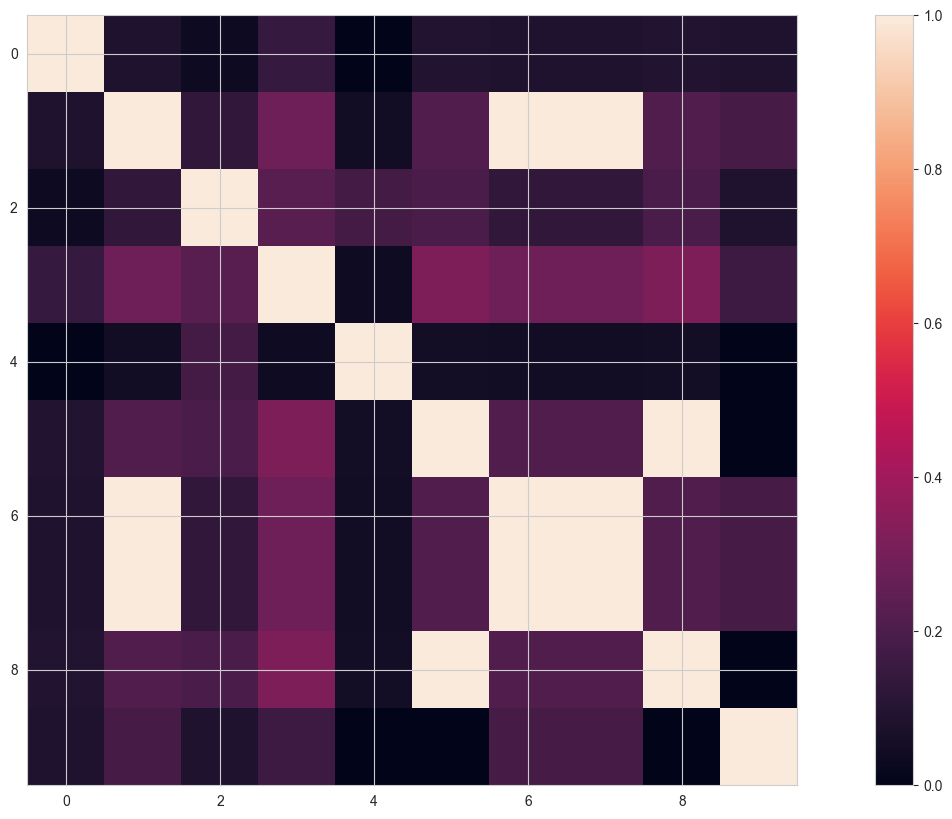

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.imshow(salida)
plt.colorbar()

### Análisis Temporal y Visualización de la Cobertura (Celda 4)
Analizaremos la intensidad de la cobertura noticiosa simulada a lo largo del tiempo, combinando ambos temas.

In [11]:
# Celda 4: Análisis Temporal
# 1. Agrupar el conteo de registros por día
cobertura_diaria = df.groupby(df['texto'].dt.date)['ID'].count().reset_index()
cobertura_diaria.columns = ['texto', 'Conteo']

# 2. Visualización: Cobertura de la Noticia por Día 
#[Image of a line chart showing daily news coverage count over time]

plt.figure(figsize=(12, 5))
sns.lineplot(data=cobertura_diaria, x='Fecha', y='Conteo', marker='o')
plt.title('Tendencia de la Cobertura Noticiosa (Simulada)')
plt.xlabel('Fecha')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Cobertura por Día de la Semana
df['Dia_Semana'] = df['Fecha'].dt.day_name()
conteo_dias = df['Dia_Semana'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).fillna(0)
print("\n--- Conteo por Día de la Semana ---\n", conteo_dias)

AttributeError: Can only use .dt accessor with datetimelike values

### Procesamiento Básico de Lenguaje Natural (NLP) (Celdas 5-6)

Para entender mejor las narrativas, extraemos las palabras más frecuentes en los comentarios de cada categoría.

In [8]:
# Celda 5: Top Palabras Clave (Generación Z)
# 1. Filtrar el texto y combinar Comentarios/Resúmenes de Gen Z
texto_genz = ' '.join(df[df['Categoria'] == 'Generacion Z']['Comentario_Reaccion'].astype(str) + ' ' +
                      df[df['Categoria'] == 'Generacion Z']['Resumen'].astype(str))

# 2. Tokenización y limpieza básica (remover puntuación y números)
texto_limpio = re.sub(r'[^\w\s]', '', texto_genz.lower())
palabras = texto_limpio.split()

# 3. Definir Stopwords (palabras comunes que no añaden valor)
stopwords_es = set(['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'un', 'una', 'con', 'es', 'del', 'por', 'se', 'las', 'más', 'su', 'sus', 'no', 'para', 'como', 'tras', 'tras', 'entre', 'sobre', 'al'])

# 4. Conteo de Palabras
from collections import Counter
conteo_palabras = Counter(p for p in palabras if p not in stopwords_es and len(p) > 3)

print("--- Top 10 Palabras Clave en Comentarios Gen Z ---\n", conteo_palabras.most_common(10))

--- Top 10 Palabras Clave en Comentarios Gen Z ---
 [('jóvenes', 15), ('protestas', 13), ('protesta', 9), ('juvenil', 7), ('calle', 7), ('movimiento', 7), ('política', 6), ('digital', 6), ('falta', 6), ('real', 6)]


In [9]:
# Celda 6: Top Palabras Clave (Frankenstein)
texto_frank = ' '.join(df[df['Categoria'] == 'Frankenstein']['Comentario_Reaccion'].astype(str) + ' ' +
                       df[df['Categoria'] == 'Frankenstein']['Resumen'].astype(str))

texto_limpio_frank = re.sub(r'[^\w\s]', '', texto_frank.lower())
palabras_frank = texto_limpio_frank.split()

# 4. Conteo de Palabras (usando las mismas stopwords)
conteo_palabras_frank = Counter(p for p in palabras_frank if p not in stopwords_es and len(p) > 3)

print("--- Top 10 Palabras Clave en Comentarios Frankenstein ---\n", conteo_palabras_frank.most_common(10))

--- Top 10 Palabras Clave en Comentarios Frankenstein ---
 [('película', 25), ('director', 23), ('toro', 17), ('monstruo', 17), ('historia', 12), ('actor', 11), ('análisis', 8), ('streaming', 6), ('pero', 6), ('final', 6)]


### Análisis de Sentimiento/Tono (Simulado) (Celda 7)
Dado que no tenemos datos de sentimiento real, crearemos un indicador de Positivismo/Negativismo simulado basado en palabras clave para cada categoría

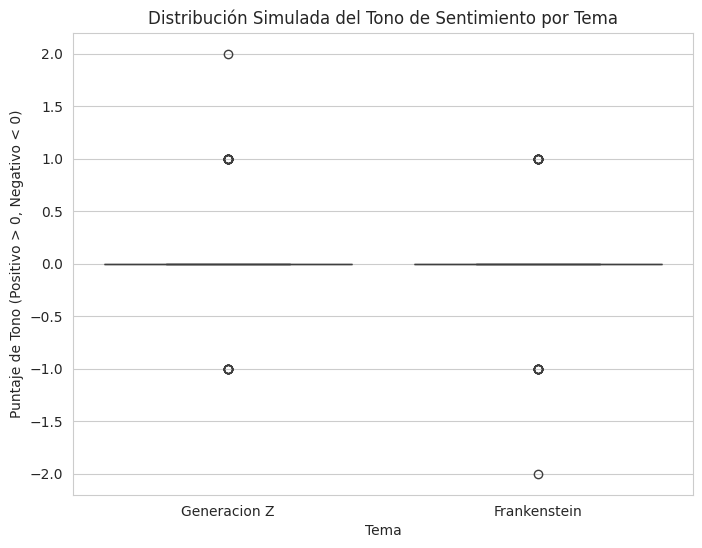


--- Tono Promedio y Desviación Estándar por Tema ---
              mean       std
Categoria                   
Frankenstein  0.00  0.492366
Generacion Z  0.08  0.506124


In [13]:
# Celda 7 (REVISADA Y MEJORADA)

# Re-definir diccionarios (puedes añadir más sinónimos si lo deseas)
sentimiento_genz = {
    'Positivo': ['esperanza', 'cambio', 'unidos', 'apoyo', 'futuro', 'despierta'],
    'Negativo': ['represion', 'violencia', 'detenidos', 'inseguridad', 'vandalismo', 'abusos'] # Sin tildes para evitar problemas
}

sentimiento_frank = {
    'Positivo': ['obra maestra', 'emocion', 'oscar', 'aplausos', 'genio', 'increible', 'joya', 'adoracion'],
    'Negativo': ['oscura', 'tragedia', 'dolor', 'miedo', 'controversia', 'tortuoso', 'nihilista', 'abandono']
}

def calcular_tono(texto, diccionario):
    """Calcula un puntaje de tono basado en la presencia de frases clave."""
    if pd.isna(texto):
        return 0
    
    # 1. Limpieza: Remover puntuación (excepto espacios) y convertir a minúsculas
    texto_limpio = re.sub(r'[^\w\s]', '', str(texto).lower())
    
    puntaje = 0
    # 2. Iterar sobre las palabras positivas y usar .count() para contarlas
    for palabra in diccionario['Positivo']:
        puntaje += texto_limpio.count(palabra)
        
    # 3. Iterar sobre las palabras negativas y restar el conteo
    for palabra in diccionario['Negativo']:
        puntaje -= texto_limpio.count(palabra)
        
    return puntaje

# 2. Aplicar la función a las categorías (EL CÓDIGO DE APLICACIÓN ES CORRECTO)
df['Tono_Sentimiento'] = 0

# Generacion Z
mask_genz = df['Categoria'] == 'Generacion Z'
df.loc[mask_genz, 'Tono_Sentimiento'] = (
    df.loc[mask_genz, 'Resumen'].astype(str) + ' ' + df.loc[mask_genz, 'Comentario_Reaccion'].astype(str)
).apply(lambda x: calcular_tono(x, sentimiento_genz))

# Frankenstein
mask_frank = df['Categoria'] == 'Frankenstein'
df.loc[mask_frank, 'Tono_Sentimiento'] = (
    df.loc[mask_frank, 'Resumen'].astype(str) + ' ' + df.loc[mask_frank, 'Comentario_Reaccion'].astype(str)
).apply(lambda x: calcular_tono(x, sentimiento_frank))

# 3. Visualización y Resumen (Continúa igual)


# 3. Visualización del Tono por Categoría 
plt.figure(figsize=(8, 6))
sns.boxplot(x='Categoria', y='Tono_Sentimiento', data=df)
plt.title('Distribución Simulada del Tono de Sentimiento por Tema')
plt.xlabel('Tema')
plt.ylabel('Puntaje de Tono (Positivo > 0, Negativo < 0)')
plt.show()

# Resumen numérico del tono
print("\n--- Tono Promedio y Desviación Estándar por Tema ---")
print(df.groupby('Categoria')['Tono_Sentimiento'].agg(['mean', 'std']))


--- Tono Promedio de Frankenstein al Mencionar al Director ---
      Menciona_Director  Tono_Sentimiento
0  No Menciona Director             0.025
1     Menciona Director            -0.100


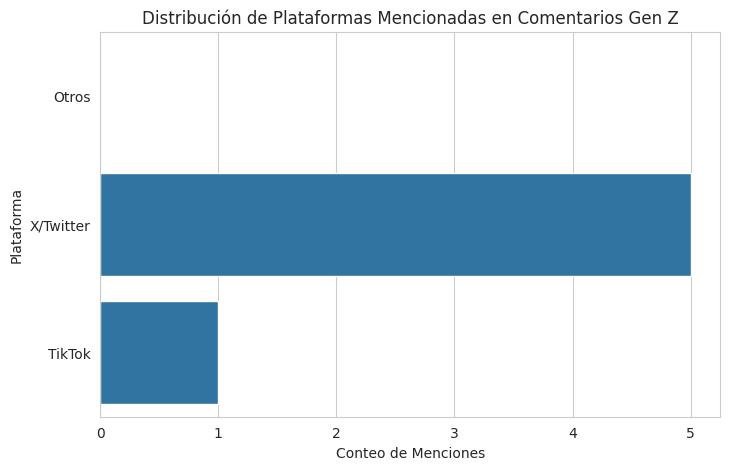

In [15]:
# Celda 8: Cruce de datos (CORREGIDA)

# ----------------------------------------------------
# ----------------------------------------------------
df_genz = df[df['Categoria'] == 'Generacion Z'].copy() 
df_frank_copy = df[df['Categoria'] == 'Frankenstein'].copy()

# ----------------------------------------------------
# 2. Influencia del Director en el Tono de Frankenstein
# ----------------------------------------------------
df_frank_copy['Menciona_Director'] = df_frank_copy['Comentario_Reaccion'].str.contains('Del Toro|GDT', case=False, na=False)

tono_por_mencion = df_frank_copy.groupby('Menciona_Director')['Tono_Sentimiento'].mean().reset_index()
tono_por_mencion['Menciona_Director'] = tono_por_mencion['Menciona_Director'].replace({True: 'Menciona Director', False: 'No Menciona Director'})

print("\n--- Tono Promedio de Frankenstein al Mencionar al Director ---")
print(tono_por_mencion)

# ----------------------------------------------------
# 3. Plataformas Sociales Mencionadas en Registros Gen Z
# ----------------------------------------------------
df_genz['Menciona_Plataforma'] = 'Otros'
df_genz.loc[df_genz['Comentario_Reaccion'].str.contains('TikTok', case=False, na=False), 'Menciona_Plataforma'] = 'TikTok'
df_genz.loc[df_genz['Comentario_Reaccion'].str.contains('Twitter|X', case=False, na=False), 'Menciona_Plataforma'] = 'X/Twitter'
df_genz.loc[df_genz['Comentario_Reaccion'].str.contains('Instagram', case=False, na=False), 'Menciona_Plataforma'] = 'Instagram'

plt.figure(figsize=(8, 5))
sns.countplot(y='Menciona_Plataforma', data=df_genz[df_genz['Menciona_Plataforma'] != 'Otros'], order=df_genz['Menciona_Plataforma'].value_counts().index)
plt.title('Distribución de Plataformas Mencionadas en Comentarios Gen Z')
plt.xlabel('Conteo de Menciones')
plt.ylabel('Plataforma')
plt.show()